# 🧠 Clasificación con Machine Learning (Titanic)

Aprenderás a entrenar y entender paso a paso varios modelos de clasificación.

## 📦 Importación de librerías

In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


## 📊 Cargar datos

In [2]:

df = pd.read_csv("..\\data\\crimeData_subconjunto.csv")
# df_test = pd.read_csv("cure_the_princess\\test.csv")
df.head()


,Unnamed: 0,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,0,10304468,01/08/2020 12:00:00 AM,01/08/2020 12:00:00 AM,2230,3,Southwest,377,2,624,...,AO,1.0,624.0,0.0,0.0,0.0,1100 W 39TH PL,NaN,34.0141,-118.2978
1,1,190101086,01/02/2020 12:00:00 AM,01/01/2020 12:00:00 AM,330,1,Central,163,2,624,...,IC,0.0,624.0,0.0,0.0,0.0,700 S HILL ST,NaN,34.0459,-118.2545
2,2,200110444,04/14/2020 12:00:00 AM,02/13/2020 12:00:00 AM,1200,1,Central,155,2,845,...,AA,2.0,845.0,0.0,0.0,0.0,200 E 6TH ST,NaN,34.0448,-118.2474
3,3,191501505,01/01/2020 12:00:00 AM,01/01/2020 12:00:00 AM,1730,15,N Hollywood,1543,2,745,...,IC,0.0,745.0,998.0,0.0,0.0,5400 CORTEEN PL,NaN,34.1685,-118.4019
4,4,191921269,01/01/2020 12:00:00 AM,01/01/2020 12:00:00 AM,415,19,Mission,1998,2,740,...,IC,0.0,740.0,0.0,0.0,0.0,14400 TITUS ST,NaN,34.2198,-118.4468


In [5]:
df.describe()

,Unnamed: 0,Phoenix Feather,Unicorn Horn,Dragon's Blood,Mermaid Tears,Fairy Dust,Goblin Toes,Witch's Brew,Griffin Claw,Troll Hair,Kraken Ink,Minotaur Horn,Basilisk Scale,Chimera Fang,Cured
count,1870.000000,1870.000000,1870.000000,1870.000000,1870.000000,1870.000000,1870.000000,1870.000000,1870.000000,1870.000000,1870.000000,1870.000000,1870.000000,1870.000000,1870.000000
mean,1175.873262,15.470963,10.869840,16.145241,13.750481,15.077540,14.166364,12.289305,14.769412,17.043422,14.916150,10.922353,15.390695,12.217326,0.494118
std,672.929407,8.721213,7.297803,8.363038,7.631516,8.301043,7.895467,7.687816,8.078848,9.598987,8.009475,7.044564,8.657294,8.148566,0.500099
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,604.500000,8.500000,5.100000,9.600000,7.600000,8.800000,7.800000,6.400000,8.300000,9.125000,8.800000,5.200000,8.700000,5.500000,0.000000
50%,1180.500000,14.800000,9.300000,15.900000,13.100000,14.500000,13.500000,11.100000,14.300000,16.500000,14.500000,9.600000,14.800000,10.700000,0.000000
75%,1744.750000,21.700000,15.500000,22.075000,19.200000,20.775000,19.675000,16.700000,20.400000,24.200000,20.500000,15.275000,21.100000,17.500000,1.000000
max,2337.000000,42.100000,34.100000,40.800000,34.100000,40.000000,37.800000,37.300000,39.400000,44.800000,39.500000,33.700000,42.000000,37.600000,1.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 757141 entries, 0 to 757140
Data columns (total 29 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Unnamed: 0      757141 non-null  int64  
 1   DR_NO           757141 non-null  int64  
 2   Date Rptd       757141 non-null  str    
 3   DATE OCC        757141 non-null  str    
 4   TIME OCC        757141 non-null  int64  
 5   AREA            757141 non-null  int64  
 6   AREA NAME       757141 non-null  str    
 7   Rpt Dist No     757141 non-null  int64  
 8   Part 1-2        757141 non-null  int64  
 9   Crm Cd          757141 non-null  int64  
 10  Crm Cd Desc     757141 non-null  str    
 11  Mocodes         653226 non-null  str    
 12  Vict Age        757141 non-null  int64  
 13  Vict Sex        757141 non-null  float64
 14  Vict Descent    757141 non-null  float64
 15  Premis Cd       757141 non-null  float64
 16  Premis Desc     756699 non-null  str    
 17  Weapon Used Cd  75714

In [4]:
df.shape

(151337, 17)

In [3]:
df.isnull().sum()

Unnamed: 0             0
DR_NO                  0
Date Rptd              0
DATE OCC               0
TIME OCC               0
AREA                   0
AREA NAME              0
Rpt Dist No            0
Part 1-2               0
Crm Cd                 0
Crm Cd Desc            0
Mocodes           103915
Vict Age               0
Vict Sex               0
Vict Descent           0
Premis Cd              0
Premis Desc          442
Weapon Used Cd         0
Weapon Desc       494062
Status                 0
Status Desc            0
Crm Cd 1               0
Crm Cd 2               0
Crm Cd 3               0
Crm Cd 4               0
LOCATION               0
Cross Street      635409
LAT                    0
LON                    0
dtype: int64

In [6]:
df=df.fillna(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

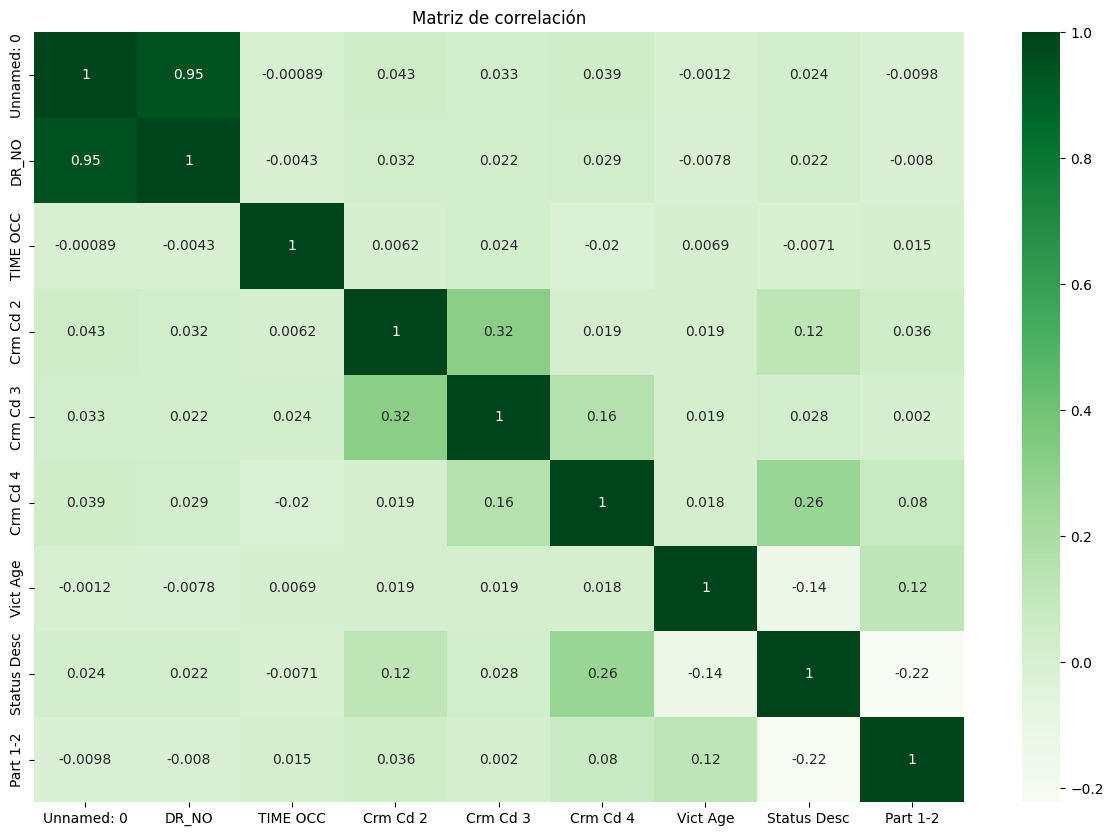

In [13]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=True, cmap="Greens")

plt.title("Matriz de correlación")

plt.show()

## 🧹 Limpieza


## 🔍 ¿Por qué dividir en Train y Test?

En Machine Learning no evaluamos el modelo con los mismos datos con los que lo entrenamos.

- **Train (entrenamiento):** el modelo aprende patrones
- **Test (evaluación):** comprobamos si generaliza bien a datos nuevos

👉 Si no hacemos esta separación, el modelo puede parecer muy bueno pero fallar en la realidad (overfitting)


In [7]:

# Ejemplo conceptual sencillo

from sklearn.model_selection import train_test_split
# df.fillna(0)
 
# Creamos datos de ejemplo
X = df[["Part 1-2", "Vict Age", "Vict Sex", "Vict Descent", "Premis Cd","Weapon Used Cd", "Crm Cd 1","Crm Cd 2","Crm Cd 3","Crm Cd 4"]]
y = df['Status Desc']

# Dividimos en 80% entrenamiento y 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (605712, 10)
Test size: (151429, 10)


In [27]:
X.columns

Index(['Unnamed: 0', 'DR_NO', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'Vict Age',
       'Part 1-2'],
      dtype='str')

## 🔀 División train/test

In [ ]:

# X = df.drop('survived', axis=1)
# y = df['survived']

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [ ]:
# X_train = df[["Witch's Brew", "Troll Hair", "Kraken Ink", "Basilisk Scale"]]
# y_train = df['Cured']
# X_test = df_test[["Witch's Brew", "Troll Hair", "Kraken Ink", "Basilisk Scale"]]
# y_test = df_test['Cured']

## ⚖️ Escalado

In [8]:

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Entrenamiento de modelos


## 🔵 Regresión Logística

### Explicación del código:
- `LogisticRegression()` crea el modelo
- `.fit(X_train, y_train)` entrena el modelo con los datos
- `.predict(X_test)` hace predicciones
- `accuracy_score` mide el rendimiento


In [9]:

model = LogisticRegression()

# Entrenamos el modelo
model.fit(X_train, y_train)

# Predecimos
preds = model.predict(X_test)
print(X_test.shape)
print(y_test.shape, preds.shape)
# Evaluamos
print("Accuracy:", accuracy_score(y_test, preds))


(151429, 10)
(151429,) (151429,)
Accuracy: 0.7952175607050169



## 🟢 KNN

### Explicación del código:
- `n_neighbors=5` → usa los 5 vecinos más cercanos
- El modelo NO aprende una fórmula → guarda los datos
- Para predecir: busca los puntos más cercanos


In [ ]:

model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))



## 🌳 Árbol de decisión

### Explicación del código:
- `max_depth=4` limita la profundidad del árbol
- El modelo crea reglas tipo:
  "si edad < 30 → ..."
- Más profundidad = más complejidad (riesgo de overfitting)


In [5]:

model = DecisionTreeClassifier(max_depth=4)

model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))


Accuracy: 1.0



## 🌲 Random Forest

### Explicación del código:
- `n_estimators=100` → número de árboles
- Cada árbol aprende algo distinto
- El resultado final es la media/votación de todos


In [6]:

model = RandomForestClassifier(n_estimators=100)

model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))


Accuracy: 1.0



## ⚫ SVM

### Explicación del código:
- Busca la mejor frontera de separación entre clases
- Usa hiperplanos (líneas en 2D)
- Muy potente en datasets complejos


In [ ]:

model = SVC()

model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
